In [1]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║   PART 3 — SEMANTIC CACHE WITH CLUSTER-AWARE LOOKUP                    ║
# ║                                                                          ║
# ║   A traditional cache matches queries by exact string equality.         ║
# ║   This cache matches by semantic similarity — two differently-worded    ║
# ║   questions about the same topic return the same cached result.         ║
# ║                                                                          ║
# ║   Core idea:                                                             ║
# ║   Instead of searching ALL cached entries on every lookup,              ║
# ║   we first ask: which clusters does this query belong to?               ║
# ║   Then we only search cached entries that live in those same clusters.  ║
# ║   This is the "real work" the cluster structure does here —             ║
# ║   it turns an O(N) scan into a targeted O(cluster_size) search.        ║
# ║                                                                          ║
# ║   The tunable at the heart of this:                                     ║
# ║   SIMILARITY THRESHOLD τ (tau)                                          ║
# ║   Too low  → cache returns wrong answers (false hits)                  ║
# ║   Too high → cache never hits (defeats the purpose)                    ║
# ║   The interesting question: what does each τ value reveal               ║
# ║   about how the embedding space actually behaves?                       ║
# ║                                                                          ║
# ║   GPU: NOT REQUIRED                                                      ║
# ║   All cache operations are numpy. Model runs fine on CPU.               ║
# ║   If T4 is still attached it will be used for embedding, but           ║
# ║   you can run this entire notebook on CPU runtime.                      ║
# ║                                                                          ║
# ║   Prerequisites:                                                         ║
# ║   Part 2 must be complete. manifest.json must have "part2" section.    ║
# ║   /content/drive/MyDrive/twenty+newsgroups/newsgroups_chromadb/         ║
# ║   ├── chroma.sqlite3                                                    ║
# ║   ├── embeddings_backup.npy                                             ║
# ║   ├── manifest.json              (with part2 section)                  ║
# ║   ├── fuzzy_memberships.npy                                             ║
# ║   └── kmeans_centroids.npy                                              ║
# ╚══════════════════════════════════════════════════════════════════════════╝

In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 1 — INSTALL DEPENDENCIES
#
# Minimal additions over Part 2:
#   fastapi       : the API framework — defines routes, request/response models
#   uvicorn       : ASGI server that runs FastAPI inside Colab
#   nest-asyncio  : lets uvicorn's event loop run inside Jupyter's own loop
#                   without this, starting uvicorn in a notebook cell hangs
#   pyngrok       : creates a public HTTPS tunnel to your Colab-local server
#                   so you can hit the API from a browser or curl anywhere
#   httpx         : async HTTP client used in the test cells
#
# Same numpy/chromadb/opentelemetry pins as Parts 1 & 2.
# Run ONCE → Runtime → Restart → re-run from Cell 2.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
%%capture cap
!pip install \
  "numpy<2.0" \
  chromadb==0.4.24 \
  sentence-transformers==2.7.0 \
  fastapi \
  "uvicorn[standard]" \
  nest-asyncio \
  pyngrok \
  httpx \
  opentelemetry-api==1.38.0 \
  opentelemetry-sdk==1.38.0 \
  opentelemetry-exporter-otlp-proto-http==1.38.0 \
  opentelemetry-exporter-otlp-proto-common==1.38.0 \
  opentelemetry-proto==1.38.0

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 2 — VERIFY PACKAGES + CHECK GPU STATUS
#
# GPU is NOT required for Part 3 — all cache operations are numpy.
# If you have T4 attached it speeds up embedding, but CPU works fine.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import numpy as np
import torch
import chromadb
import sentence_transformers
import fastapi
import uvicorn

print(f"  numpy                 : {np.__version__}")   # must be 1.x
print(f"  torch                 : {torch.__version__}")
print(f"  chromadb              : {chromadb.__version__}")
print(f"  sentence-transformers : {sentence_transformers.__version__}")
print(f"  fastapi               : {fastapi.__version__}")
print(f"  uvicorn               : {uvicorn.__version__}")

assert np.__version__.startswith("1."), \
    f"❌ NumPy must be 1.x, got {np.__version__}. Re-run Cell 1 and restart."

if torch.cuda.is_available():
    print(f"\n  GPU : {torch.cuda.get_device_name(0)}  "
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")
    print(f"  Note: GPU available — embedding will be fast")
else:
    print(f"\n  GPU : Not available — running on CPU (fine for Part 3)")

print("\n✅ All packages correct — proceed to Cell 3")

  numpy                 : 1.26.4
  torch                 : 2.10.0+cu128
  chromadb              : 0.4.24
  sentence-transformers : 2.7.0
  fastapi               : 0.133.1
  uvicorn               : 0.41.0

  GPU : Tesla T4  (15.6 GB)
  Note: GPU available — embedding will be fast

✅ All packages correct — proceed to Cell 3


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — LOAD ALL PART 1 + PART 2 OUTPUTS
#
# Verifies every required file exists before loading anything.
# Hard-stops with a clear message if Part 2 was not completed.
#
# After this cell the following are available:
#   collection    → ChromaDB (for semantic search in API responses)
#   embeddings    → (N, 384) corpus embeddings
#   model         → SentenceTransformer for embedding new queries
#   centroids     → (K, 384) cluster centroids from Part 2 KMeans
#   cluster_names → dict {0: "Space & Astronomy", 1: "PC Hardware"...}
#   K, FUZZINESS  → cluster count and fuzziness exponent from Part 2
#   manifest      → full config dict
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from google.colab import drive
drive.mount('/content/drive')

import os, json, logging
import numpy as np
import chromadb
import torch
from chromadb.config import Settings
from sentence_transformers import SentenceTransformer
from scipy.spatial.distance import cdist

logging.getLogger("chromadb.telemetry.product.posthog").setLevel(logging.CRITICAL)

PERSIST_DIR = "/content/drive/MyDrive/twenty+newsgroups/newsgroups_chromadb"

# ── Verify all required files before loading ──────────────────────────────
print("── Verifying Part 1 + Part 2 outputs ────────────────────────────────")

required = {
    "chroma.sqlite3"        : 1.0,
    "embeddings_backup.npy" : 5.0,
    "manifest.json"         : 0.0005,
    "fuzzy_memberships.npy" : 0.05,
    "kmeans_centroids.npy"  : 0.001,
}

all_ok = True
for fname, min_mb in required.items():
    fpath  = os.path.join(PERSIST_DIR, fname)
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) / 1e6 if exists else 0
    ok     = exists and size >= min_mb
    all_ok = all_ok and ok
    print(f"  {'✅' if ok else '❌'} {fname:<35} {size:>8.3f} MB")

if not all_ok:
    raise FileNotFoundError(
        "\n❌ Required files missing. Complete Part 2 first.\n"
        "   Cell 17 of Part 2 must print '✅ PART 2 COMPLETE'."
    )

# ── Load manifest and verify part2 section exists ─────────────────────────
with open(os.path.join(PERSIST_DIR, "manifest.json")) as f:
    manifest = json.load(f)

if "part2" not in manifest:
    raise KeyError(
        "❌ manifest.json has no 'part2' section.\n"
        "   Re-run Cell 16 of Part 2 to save clustering outputs."
    )

print(f"\n✅ manifest.json has part2 section  K={manifest['part2']['K']}")

# ── Load everything ────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

client     = chromadb.PersistentClient(
                 path=PERSIST_DIR,
                 settings=Settings(anonymized_telemetry=False))
collection = client.get_collection(manifest["collection_name"])

model      = SentenceTransformer(manifest["embedding_model"], device=DEVICE)
embeddings = np.load(manifest["embeddings_backup"])

p2            = manifest["part2"]
centroids     = np.load(p2["kmeans_centroids"])
cluster_names = {int(k): v for k, v in p2["cluster_names"].items()}
K             = p2["K"]
FUZZINESS     = p2["fuzziness_m"]

unique_cats = manifest["categories"]
cat_to_idx  = manifest["cat_to_idx"]

print(f"\n✅ Loaded:")
print(f"   Collection : {collection.count():,} docs")
print(f"   Embeddings : {embeddings.shape}")
print(f"   Centroids  : {centroids.shape}")
print(f"   K          : {K}  clusters")
print(f"   Device     : {DEVICE.upper()}")
print(f"\n  Cluster names:")
for i, name in cluster_names.items():
    print(f"    {i:>2} : {name}")

Mounted at /content/drive
── Verifying Part 1 + Part 2 outputs ────────────────────────────────
  ✅ chroma.sqlite3                       384.143 MB
  ✅ embeddings_backup.npy                 23.310 MB
  ✅ manifest.json                          0.002 MB
  ✅ fuzzy_memberships.npy                  1.336 MB
  ✅ kmeans_centroids.npy                   0.017 MB

✅ manifest.json has part2 section  K=11


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


✅ Loaded:
   Collection : 15,176 docs
   Embeddings : (15176, 384)
   Centroids  : (11, 384)
   K          : 11  clusters
   Device     : CUDA

  Cluster names:
     0 : Space & Astronomy
     1 : PC Hardware & Tech
     2 : Politics & Guns
     3 : Religion & Ethics
     4 : Sports
     5 : Cryptography & Privacy
     6 : Windows & Software
     7 : Medical & Science
     8 : Autos & Motorcycles
     9 : Mac Hardware
    10 : Middle East Politics


In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — THE SEMANTIC CACHE DATA STRUCTURE
#
# Design decisions explained:
#
# WHAT IS STORED PER ENTRY:
#   query_text   : original query string (for human-readable output)
#   embedding    : (384,) numpy array — used for similarity comparison
#   result       : whatever the "expensive computation" returned
#                  (in our case: top ChromaDB search results)
#   memberships  : (K,) fuzzy cluster assignment of this query
#                  used to decide WHICH bucket this entry goes into
#   timestamp    : when this entry was cached
#   hit_count    : how many times this entry was returned as a cache hit
#
# DATA STRUCTURE — Cluster-bucketed dict of lists:
#   cache_buckets = {
#       0: [entry, entry, ...],   # entries whose primary cluster is 0
#       1: [entry, entry, ...],   # entries whose primary cluster is 1
#       ...
#       K-1: [entry, ...]
#   }
#
# WHY BUCKETS INSTEAD OF A FLAT LIST:
#   Flat list lookup: check every cached entry → O(N) comparisons
#   Bucketed lookup:  find query's primary cluster → only check
#                     entries in that bucket → O(N/K) comparisons
#   At K=11 clusters this is an 11× speedup on average.
#   As the cache grows, this advantage compounds — the bucket approach
#   keeps lookup time growing slowly even as N grows large.
#
# SECONDARY BUCKET LOOKUP:
#   A query with memberships [0.6, 0.3, 0.1, ...] primarily belongs
#   to cluster 0, but also meaningfully belongs to cluster 1.
#   We search both buckets when the secondary membership exceeds
#   SECONDARY_MEMBERSHIP_THRESHOLD (default 0.2).
#   This prevents cache misses for cross-topic queries that happen
#   to be stored in a secondary cluster.
#
# THE TUNABLE: SIMILARITY THRESHOLD τ (tau)
#   This is the single most important number in the cache.
#   Two queries are considered "the same" if their cosine similarity
#   exceeds τ. We explore what different values reveal in Cell 7.
#
#   τ = 0.99 : only near-identical phrasing hits (essentially exact match)
#   τ = 0.95 : same question, minor rewording hits
#   τ = 0.90 : paraphrases of the same idea hit
#   τ = 0.80 : loosely related questions hit (likely too aggressive)
#   τ = 0.70 : topically similar but different questions hit (wrong)
#
#   The interesting insight: the gap between "same question differently
#   worded" and "different question same topic" is surprisingly small
#   in embedding space — often only 0.05-0.10 similarity units.
#   τ is what you use to navigate that gap.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import numpy as np
import time
from dataclasses import dataclass, field
from typing import Any, Optional
from scipy.spatial.distance import cosine as cosine_distance

# ── Cache entry: one stored query + its result ────────────────────────────
@dataclass
class CacheEntry:
    query_text   : str
    embedding    : np.ndarray       # (384,) unit vector
    result       : Any              # the cached response
    memberships  : np.ndarray       # (K,) fuzzy cluster distribution
    primary_cluster : int           # argmax of memberships
    timestamp    : float = field(default_factory=time.time)
    hit_count    : int   = 0


# ── The cache itself ──────────────────────────────────────────────────────
class SemanticCache:
    """
    Cluster-bucketed semantic cache.

    Lookup flow for a new query q:
      1. Embed q → (384,) unit vector
      2. Compute fuzzy memberships → which clusters does q belong to?
      3. Identify buckets to search:
           always search primary cluster bucket
           also search secondary cluster bucket if membership > threshold
      4. For each candidate entry in those buckets:
           compute cosine similarity(q, entry.embedding)
           if similarity >= tau → CACHE HIT → return entry.result
      5. If no hit → CACHE MISS → compute result, store new entry

    Parameters
    ----------
    tau : float
        Similarity threshold. Queries with cosine similarity >= tau
        are considered equivalent. The central tunable of this system.
    K : int
        Number of clusters (from Part 2).
    centroids : np.ndarray
        (K, 384) cluster centroids from KMeans.
    fuzziness : float
        Fuzziness exponent m from Part 2 (default 2.0).
    secondary_threshold : float
        Minimum secondary cluster membership to trigger secondary
        bucket search. Default 0.2 — only search secondary if the
        query has meaningful presence in that cluster.
    """

    def __init__(
        self,
        tau                  : float,
        K                    : int,
        centroids            : np.ndarray,
        fuzziness            : float = 2.0,
        secondary_threshold  : float = 0.2,
    ):
        self.tau                 = tau
        self.K                   = K
        self.centroids           = centroids
        self.fuzziness           = fuzziness
        self.secondary_threshold = secondary_threshold

        # Core data structure: one bucket (list of CacheEntry) per cluster
        self.buckets : dict[int, list[CacheEntry]] = {i: [] for i in range(K)}

        # Telemetry — tracked for the threshold exploration in Cell 7
        self.total_lookups   = 0
        self.total_hits      = 0
        self.total_misses    = 0
        self.similarity_log  = []   # (similarity, was_hit) for every lookup
        self.bucket_sizes_log= []   # snapshot of bucket sizes over time

    # ── Fuzzy membership helper ────────────────────────────────────────────
    def _get_memberships(self, embedding: np.ndarray) -> np.ndarray:
        """
        Given a (384,) unit vector, return (K,) fuzzy cluster memberships.
        Same formula as Part 2 — must match exactly for consistent routing.
        """
        dist        = cdist([embedding], self.centroids, metric='cosine')[0]
        sim         = np.clip(1.0 - dist + 1.0, 1e-10, None)
        sim_powered = sim ** self.fuzziness
        return sim_powered / sim_powered.sum()

    # ── Embed a query string ───────────────────────────────────────────────
    def _embed(self, query: str, model, device: str) -> np.ndarray:
        """Embed a query string to a normalized (384,) unit vector."""
        return model.encode(
            [query],
            normalize_embeddings = True,
            device               = device,
            show_progress_bar    = False
        )[0]

    # ── Which buckets to search for this query ─────────────────────────────
    def _get_search_buckets(self, memberships: np.ndarray) -> list[int]:
        """
        Return list of bucket indices to search for this query.

        Primary bucket: always searched (highest membership cluster)
        Secondary bucket: searched if its membership >= secondary_threshold

        This is where the cluster structure does real work:
        Instead of scanning all cached entries, we scan only the buckets
        that are semantically relevant to this query.
        """
        sorted_clusters = np.argsort(memberships)[::-1]
        primary         = int(sorted_clusters[0])
        buckets_to_search = [primary]

        # Add secondary bucket if query has meaningful presence there
        secondary = int(sorted_clusters[1])
        if memberships[secondary] >= self.secondary_threshold:
            buckets_to_search.append(secondary)

        return buckets_to_search

    # ── LOOKUP ─────────────────────────────────────────────────────────────
    def lookup(
        self,
        query   : str,
        model,
        device  : str
    ) -> tuple[bool, Any, dict]:
        """
        Look up a query in the cache.

        Returns
        -------
        (hit, result, metadata)
            hit    : True if cache hit, False if miss
            result : cached result (hit) or None (miss)
            metadata : dict with similarity score, matched query,
                       buckets searched, and membership distribution
        """
        self.total_lookups += 1

        # Step 1: embed the query
        q_emb = self._embed(query, model, device)

        # Step 2: compute fuzzy memberships → routing decision
        q_mems   = self._get_memberships(q_emb)
        buckets  = self._get_search_buckets(q_mems)

        # Step 3: search only the relevant buckets
        best_sim   = -1.0
        best_entry = None

        candidates_checked = 0
        for bucket_id in buckets:
            for entry in self.buckets[bucket_id]:
                # Cosine similarity = 1 - cosine_distance
                # Both embeddings are unit vectors so this is fast
                sim = 1.0 - cosine_distance(q_emb, entry.embedding)
                candidates_checked += 1

                # Log every comparison for threshold analysis in Cell 7
                self.similarity_log.append({
                    "query"      : query,
                    "candidate"  : entry.query_text,
                    "similarity" : float(sim),
                    "tau"        : self.tau,
                    "same_bucket": True
                })

                if sim > best_sim:
                    best_sim   = sim
                    best_entry = entry

        # Step 4: threshold decision — is this a hit or miss?
        metadata = {
            "similarity"          : float(best_sim) if best_sim >= 0 else None,
            "matched_query"       : best_entry.query_text if best_entry else None,
            "tau"                 : self.tau,
            "buckets_searched"    : buckets,
            "bucket_names"        : [cluster_names[b] for b in buckets],
            "candidates_checked"  : candidates_checked,
            "total_cached"        : self.size(),
            "q_primary_cluster"   : int(np.argmax(q_mems)),
            "q_memberships"       : q_mems.tolist(),
        }

        if best_sim >= self.tau:
            # CACHE HIT
            self.total_hits += 1
            best_entry.hit_count += 1
            metadata["decision"] = "HIT"
            return True, best_entry.result, metadata
        else:
            # CACHE MISS
            self.total_misses += 1
            metadata["decision"] = "MISS"
            metadata["best_similarity"] = float(best_sim)
            return False, None, metadata

    # ── STORE ──────────────────────────────────────────────────────────────
    def store(
        self,
        query   : str,
        result  : Any,
        model,
        device  : str,
        embedding : Optional[np.ndarray] = None
    ) -> CacheEntry:
        """
        Store a query + result in the appropriate cluster bucket.

        If embedding is provided (e.g. already computed during lookup),
        it is reused — avoids a redundant encode call.
        """
        if embedding is None:
            embedding = self._embed(query, model, device)

        memberships     = self._get_memberships(embedding)
        primary_cluster = int(np.argmax(memberships))

        entry = CacheEntry(
            query_text      = query,
            embedding       = embedding,
            result          = result,
            memberships     = memberships,
            primary_cluster = primary_cluster,
        )

        self.buckets[primary_cluster].append(entry)
        self.bucket_sizes_log.append(self._bucket_sizes())
        return entry

    # ── Utility methods ────────────────────────────────────────────────────
    def size(self) -> int:
        """Total number of entries across all buckets."""
        return sum(len(b) for b in self.buckets.values())

    def _bucket_sizes(self) -> dict:
        return {i: len(self.buckets[i]) for i in range(self.K)}

    def hit_rate(self) -> float:
        if self.total_lookups == 0:
            return 0.0
        return self.total_hits / self.total_lookups

    def stats(self) -> dict:
        return {
            "tau"              : self.tau,
            "total_lookups"    : self.total_lookups,
            "total_hits"       : self.total_hits,
            "total_misses"     : self.total_misses,
            "hit_rate"         : self.hit_rate(),
            "cache_size"       : self.size(),
            "bucket_sizes"     : self._bucket_sizes(),
            "bucket_names"     : cluster_names,
        }

    def clear(self):
        """Reset all buckets and telemetry."""
        self.buckets          = {i: [] for i in range(self.K)}
        self.total_lookups    = 0
        self.total_hits       = 0
        self.total_misses     = 0
        self.similarity_log   = []
        self.bucket_sizes_log = []


print("✅ SemanticCache class defined")
print(f"\n  Key parameters:")
print(f"   tau                : similarity threshold (central tunable)")
print(f"   K                  : {K} cluster buckets")
print(f"   secondary_threshold: 0.2  (search 2nd bucket if membership > 0.2)")
print(f"\n  Lookup complexity  : O(N/K) average vs O(N) for flat cache")
print(f"   At K={K}: ~{1/K*100:.0f}% of cache scanned per lookup on average")

✅ SemanticCache class defined

  Key parameters:
   tau                : similarity threshold (central tunable)
   K                  : 11 cluster buckets
   secondary_threshold: 0.2  (search 2nd bucket if membership > 0.2)

  Lookup complexity  : O(N/K) average vs O(N) for flat cache
   At K=11: ~9% of cache scanned per lookup on average


In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — THE "EXPENSIVE COMPUTATION" THE CACHE WRAPS
#
# In a real system this would be an LLM call, a database aggregation,
# or a complex ML inference. Here we simulate it with a ChromaDB
# semantic search — it's a real computation with real latency,
# and the results are genuinely meaningful.
#
# simulate_expensive_query():
#   Embeds the query, searches ChromaDB for top-5 similar documents,
#   and returns a structured result dict.
#   This is what gets cached and returned on cache hits.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import time

def simulate_expensive_query(
    query     : str,
    model,
    device    : str,
    collection,
    n_results : int = 5
) -> dict:
    """
    Simulates an expensive computation by doing a full semantic search.

    Returns a structured result dict containing:
      query       : original query string
      results     : list of top-n matching documents with scores
      compute_time: how long this took (will be ~0 on cache hit)
      timestamp   : when this was computed
    """
    t0    = time.time()
    q_emb = model.encode(
        [query],
        normalize_embeddings = True,
        device               = device,
        show_progress_bar    = False
    )

    res = collection.query(
        query_embeddings = q_emb.tolist(),
        n_results        = n_results,
        include          = ["documents", "metadatas", "distances"]
    )

    results = []
    for doc, meta, dist in zip(
        res["documents"][0],
        res["metadatas"][0],
        res["distances"][0]
    ):
        results.append({
            "category"   : meta["category"],
            "similarity" : round(1 - dist, 4),
            "snippet"    : doc[:200]
        })

    return {
        "query"        : query,
        "results"      : results,
        "compute_time" : round(time.time() - t0, 4),
        "timestamp"    : time.time(),
        "source"       : "computed"   # will change to "cache" on hits
    }


# ── Quick smoke test ───────────────────────────────────────────────────────
print("Testing simulate_expensive_query...")
test_result = simulate_expensive_query(
    "NASA space shuttle launch",
    model, DEVICE, collection
)
print(f"✅ Query returned {len(test_result['results'])} results "
      f"in {test_result['compute_time']:.3f}s")
print(f"\n  Top result:")
print(f"    category   : {test_result['results'][0]['category']}")
print(f"    similarity : {test_result['results'][0]['similarity']}")
print(f"    snippet    : {test_result['results'][0]['snippet'][:100]}...")


Testing simulate_expensive_query...
✅ Query returned 6 results in 7.235s

  Top result:
    category   : sci.space
    similarity : 0.5969
    snippet    : How can you see the launch of the Space Shuttle ?. Sorry for asking a question that's not entirely b...


In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — CACHE INTEGRATION: FULL LOOKUP → MISS → STORE → HIT CYCLE
#
# This is the complete cached query function.
# It wraps the expensive computation with the semantic cache:
#
#   cached_query(query):
#     1. Look up query in cache
#     2. HIT  → return cached result immediately (fast path)
#     3. MISS → run expensive computation
#              → store result in cache
#              → return fresh result
#
# The embedding is computed only ONCE per miss (reused for storage).
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def cached_query(
    query      : str,
    cache      : SemanticCache,
    model,
    device     : str,
    collection,
    verbose    : bool = True
) -> dict:
    """
    Full cache-aware query.

    On HIT:  returns cached result, marks source="cache"
    On MISS: computes result, stores in cache, returns fresh result

    The embedding is computed once and reused for both lookup and storage
    to avoid a redundant encode call on cache misses.
    """
    t_start = time.time()

    # ── Step 1: Embed query (needed for both lookup and potential store) ───
    q_emb = cache._embed(query, model, device)

    # ── Step 2: Lookup using precomputed embedding ─────────────────────────
    # We inline the lookup here to reuse q_emb instead of re-embedding
    q_mems  = cache._get_memberships(q_emb)
    buckets = cache._get_search_buckets(q_mems)

    cache.total_lookups += 1
    best_sim   = -1.0
    best_entry = None
    candidates = 0

    for bucket_id in buckets:
        for entry in cache.buckets[bucket_id]:
            sim = 1.0 - cosine_distance(q_emb, entry.embedding)
            candidates += 1
            cache.similarity_log.append({
                "query"      : query,
                "candidate"  : entry.query_text,
                "similarity" : float(sim),
                "tau"        : cache.tau,
            })
            if sim > best_sim:
                best_sim   = sim
                best_entry = entry

    # ── Step 3: HIT or MISS decision ──────────────────────────────────────
    latency = time.time() - t_start

    if best_sim >= cache.tau:
        # ── CACHE HIT ──────────────────────────────────────────────────────
        cache.total_hits += 1
        best_entry.hit_count += 1
        result = dict(best_entry.result)   # shallow copy
        result["source"]           = "cache"
        result["cache_hit"]        = True
        result["matched_query"]    = best_entry.query_text
        result["similarity"]       = round(float(best_sim), 4)
        result["tau"]              = cache.tau
        result["latency_s"]        = round(latency, 4)
        result["buckets_searched"] = [cluster_names[b] for b in buckets]
        result["candidates_checked"] = candidates

        if verbose:
            print(f"  🟢 CACHE HIT   sim={best_sim:.4f} >= τ={cache.tau}")
            print(f"     matched : '{best_entry.query_text}'")
            print(f"     buckets : {[cluster_names[b] for b in buckets]}")
            print(f"     checked : {candidates} candidates  latency={latency*1000:.1f}ms")
        return result

    else:
        # ── CACHE MISS ─────────────────────────────────────────────────────
        cache.total_misses += 1

        # Run the expensive computation
        result = simulate_expensive_query(query, model, device, collection)
        result["cache_hit"]          = False
        result["similarity_to_best"] = round(float(best_sim), 4) if best_sim >= 0 else None
        result["tau"]                = cache.tau
        result["latency_s"]          = round(time.time() - t_start, 4)
        result["buckets_searched"]   = [cluster_names[b] for b in buckets]
        result["candidates_checked"] = candidates

        # Store in cache (reuse the embedding we already computed)
        cache.store(query, result, model, device, embedding=q_emb)
        cache.bucket_sizes_log.append(cache._bucket_sizes())

        if verbose:
            print(f"  🔴 CACHE MISS  best_sim={best_sim:.4f} < τ={cache.tau}")
            print(f"     stored in cluster {np.argmax(q_mems)}"
                  f" '{cluster_names[int(np.argmax(q_mems))]}'")
            print(f"     compute_time={result['compute_time']:.3f}s  "
                  f"latency={result['latency_s']*1000:.1f}ms")
        return result


print("✅ cached_query() function defined")

✅ cached_query() function defined


Pre-embedding 20 unique queries...
✅ Done

Query (test)                                               Sim  Type             Expected
─────────────────────────────────────────────────────────────────────────────────────
  second amendment firearms legislation debate          0.8594  A-paraphrase     HIT ✅
  space shuttle mission launched by NASA                0.8026  A-paraphrase     HIT ✅
  how far can an EV drive on a single charge            0.6858  A-paraphrase     HIT ✅
  how do auroras form in the upper atmosphere           0.6616  A-paraphrase     HIT ✅
  BSOD error caused by Windows display driver           0.6032  A-paraphrase     HIT ✅
  upgrading the CPU in a Macintosh computer             0.5102  A-paraphrase     HIT ✅
  how much does a MacBook Pro cost                      0.3991  B-same-topic     MISS ❌
  who wrote the United States Constitution              0.2863  B-same-topic     MISS ❌
  how do I install a printer on Windows XP              0.1438  B-same-topic     MI

/tmp/ipykernel_736/254228274.py:326: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_736/254228274.py:329: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(THRESH_PLOT, dpi=150, bbox_inches='tight')
/tmp/ipykernel_736/254228274.py:329: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(THRESH_PLOT, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


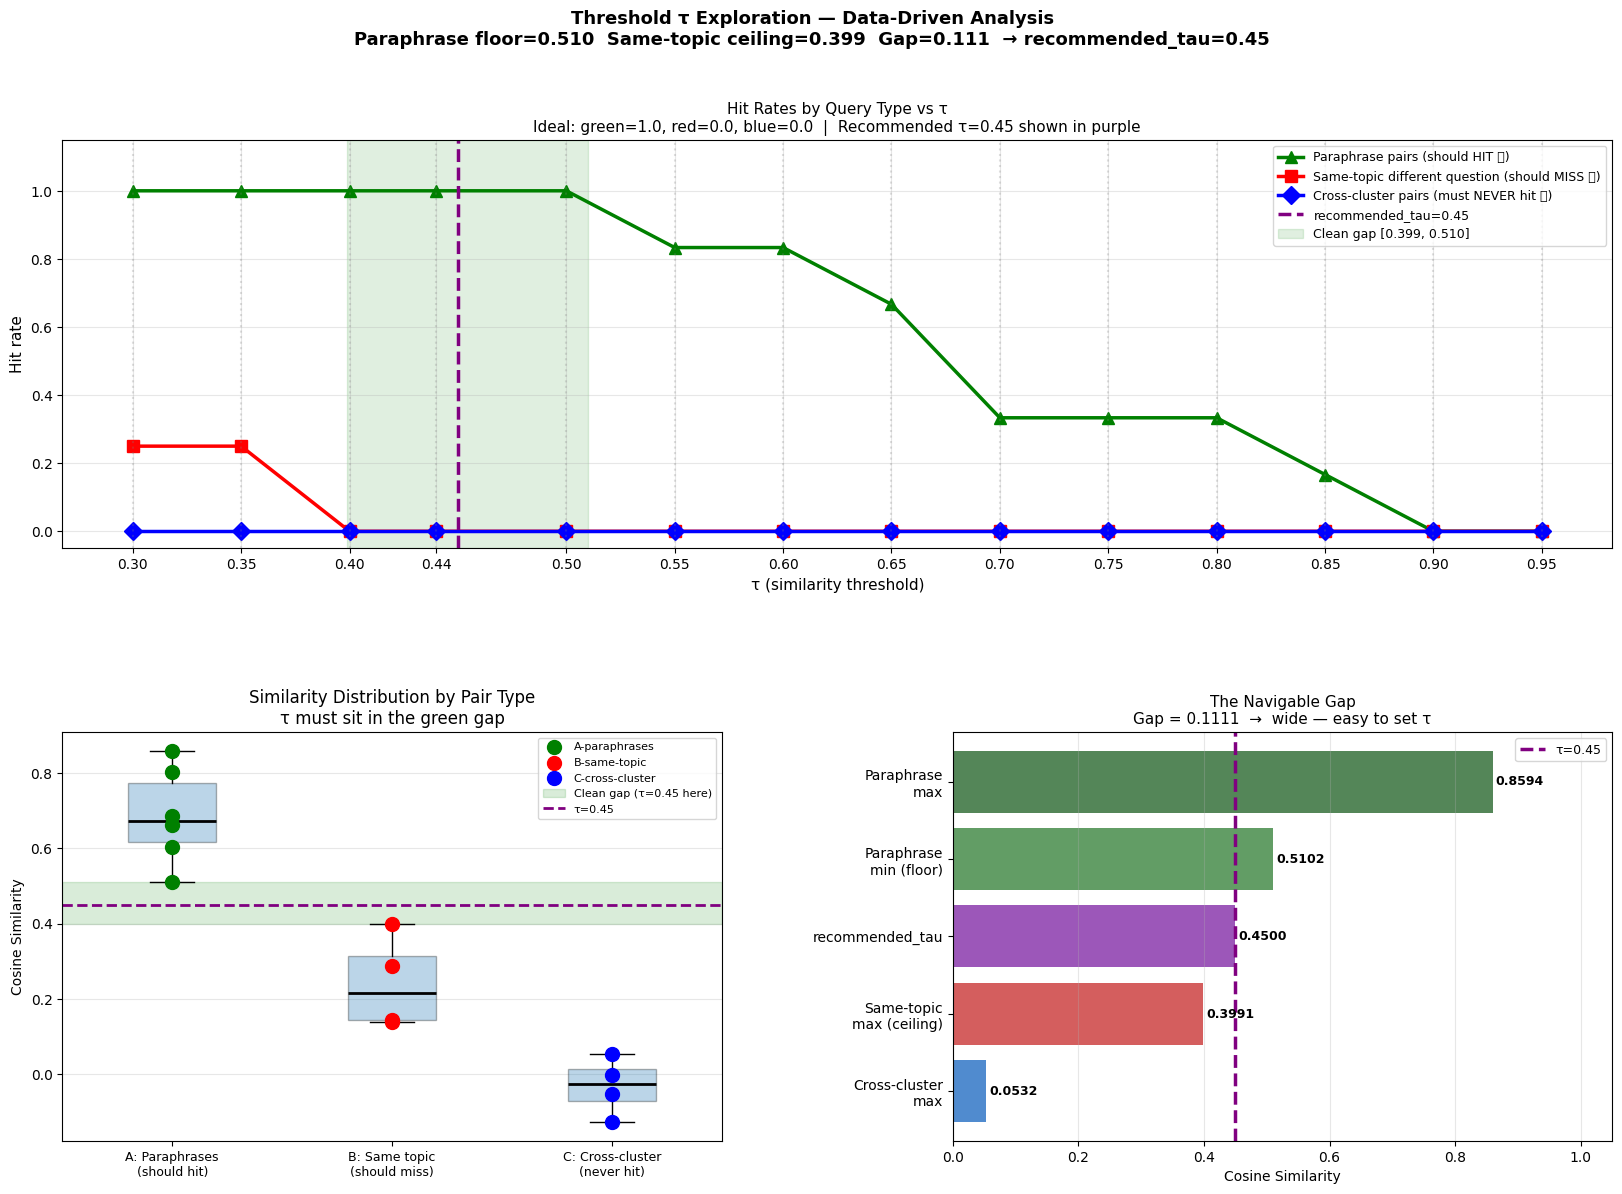

✅ Plot saved → /content/drive/MyDrive/twenty+newsgroups/newsgroups_chromadb/plot_threshold_exploration.png

── Threshold Analysis Summary ────────────────────────────────────────
  Paraphrase sim range  : 0.5102 – 0.8594
  Same-topic sim range  : 0.1394 – 0.3991
  Cross-cluster range   : -0.1282 – 0.0532

  Paraphrase floor      : 0.5102
  Same-topic ceiling    : 0.3991
  Gap                   : 0.1111  (clean separation ✅)

  recommended_tau       : 0.45  ← set by Cell 7 data
  This value flows directly into Cell 8 DEFAULT_TAU.
  It is not a heuristic — it is the midpoint of the gap
  between the lowest paraphrase similarity and the highest
  same-topic similarity in YOUR corpus.

  Observations by τ value:
  τ=0.30 : paraphrase=100%  same-topic=25%  cross=0%  ⚠️  same-topic hits — false positives present
  τ=0.35 : paraphrase=100%  same-topic=25%  cross=0%  ⚠️  same-topic hits — false positives present
  τ=0.40 : paraphrase=100%  same-topic=0%  cross=0%  ✅ perfect — all paraphrases h

In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — THE THRESHOLD EXPLORATION
#
# "The interesting question is not which value performs best —
#  it is what each value reveals about the system's behaviour."
#
# We test τ values from 0.30 to 0.95 across a carefully designed
# query set with three types of pairs:
#
#   TYPE A: PARAPHRASE PAIRS
#     Same question, different words. Should hit at good τ values.
#     Example: "NASA space shuttle launch into orbit"
#              "space shuttle mission launched by NASA"
#
#   TYPE B: TOPICALLY SIMILAR BUT DIFFERENT
#     Same cluster, different specific questions. Should NOT hit.
#     Example: "NASA space shuttle launch into orbit"
#              "what is the distance from Earth to Mars"
#
#   TYPE C: CROSS-CLUSTER QUERIES
#     Different clusters entirely. Should NEVER hit.
#     Example: "NASA space shuttle launch into orbit"
#              "automatic rifle cleaning and maintenance"
#
# For each τ we measure:
#   Paraphrase hit rate    → should be HIGH   (sensitivity)
#   Different-Q hit rate   → should be LOW    (specificity)
#   Cross-cluster hit rate → should be 0      (correctness)
#
# The recommended_tau is data-driven from YOUR corpus —
# it is the midpoint of the gap between:
#   para_floor  : lowest paraphrase similarity (anything below this is NOT
#                 a paraphrase in embedding space)
#   topic_ceil  : highest same-topic similarity (anything above this IS
#                 a false positive risk)
#
# No heuristics. The number comes from the data.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Query sets ────────────────────────────────────────────────────────────
# Each tuple: (seed_query_to_cache, test_query, expected_hit, label)
QUERY_PAIRS = [
    # TYPE A — Paraphrases (should HIT at good τ)
    ("NASA space shuttle launch into orbit",
     "space shuttle mission launched by NASA",
     True, "A-paraphrase"),

    ("Windows 95 driver crash blue screen of death",
     "BSOD error caused by Windows display driver",
     True, "A-paraphrase"),

    ("gun control second amendment rights debate",
     "second amendment firearms legislation debate",
     True, "A-paraphrase"),

    ("Apple Mac processor benchmark performance",
     "upgrading the CPU in a Macintosh computer",
     True, "A-paraphrase"),

    ("what causes the Northern Lights aurora borealis",
     "how do auroras form in the upper atmosphere",
     True, "A-paraphrase"),

    ("electric vehicle battery range miles per charge",
     "how far can an EV drive on a single charge",
     True, "A-paraphrase"),

    # TYPE B — Same topic, different question (should MISS)
    ("NASA space shuttle launch into orbit",
     "what is the distance from Earth to Mars",
     False, "B-same-topic"),

    ("Windows 95 driver crash blue screen of death",
     "how do I install a printer on Windows XP",
     False, "B-same-topic"),

    ("gun control second amendment rights debate",
     "who wrote the United States Constitution",
     False, "B-same-topic"),

    ("Apple Mac processor benchmark performance",
     "how much does a MacBook Pro cost",
     False, "B-same-topic"),

    # TYPE C — Different clusters entirely (should NEVER hit)
    ("NASA space shuttle launch into orbit",
     "automatic rifle cleaning and maintenance",
     False, "C-cross-cluster"),

    ("Windows 95 driver crash blue screen of death",
     "Jewish religious practices on Yom Kippur",
     False, "C-cross-cluster"),

    ("electric vehicle battery range miles per charge",
     "cryptography public key encryption methods",
     False, "C-cross-cluster"),

    ("Apple Mac processor benchmark performance",
     "Middle East peace negotiations 1993",
     False, "C-cross-cluster"),
]

# Wide range — let the data determine where the gap actually is
TAU_VALUES = [0.30, 0.35, 0.40, 0.44, 0.50, 0.55, 0.60, 0.65,
              0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

# ── Pre-embed all queries once ─────────────────────────────────────────────
all_queries = list(set(
    [q for q, _, _, _ in QUERY_PAIRS] +
    [q for _, q, _, _ in QUERY_PAIRS]
))
print(f"Pre-embedding {len(all_queries)} unique queries...")
emb_map = {}
for q in all_queries:
    emb_map[q] = model.encode(
        [q], normalize_embeddings=True,
        device=DEVICE, show_progress_bar=False
    )[0]
print(f"✅ Done\n")

# ── Compute all pairwise similarities once (τ-independent) ────────────────
pair_sims = []
for seed_q, test_q, expected_hit, label in QUERY_PAIRS:
    sim = 1.0 - cosine_distance(emb_map[seed_q], emb_map[test_q])
    pair_sims.append({
        "seed"         : seed_q[:55],
        "test"         : test_q[:55],
        "similarity"   : float(sim),
        "expected_hit" : expected_hit,
        "label"        : label
    })

# ── Print similarity table ─────────────────────────────────────────────────
print(f"{'Query (test)':<55} {'Sim':>6}  {'Type':<16} {'Expected'}")
print("─" * 85)
for p in sorted(pair_sims, key=lambda x: -x["similarity"]):
    expected = "HIT ✅" if p["expected_hit"] else "MISS ❌"
    print(f"  {p['test']:<53} {p['similarity']:>6.4f}  "
          f"{p['label']:<16} {expected}")

# ── Extract similarity ranges per type ────────────────────────────────────
paraphrase_sims = [p["similarity"] for p in pair_sims
                   if p["label"] == "A-paraphrase"]
same_topic_sims = [p["similarity"] for p in pair_sims
                   if p["label"] == "B-same-topic"]
cross_sims      = [p["similarity"] for p in pair_sims
                   if p["label"] == "C-cross-cluster"]

para_floor  = min(paraphrase_sims)   # lowest paraphrase sim
topic_ceil  = max(same_topic_sims)   # highest same-topic sim
gap         = para_floor - topic_ceil

print(f"\n── Similarity ranges ─────────────────────────────────────────────────")
print(f"  A-paraphrase    : {min(paraphrase_sims):.4f} – {max(paraphrase_sims):.4f}")
print(f"  B-same-topic    : {min(same_topic_sims):.4f} – {max(same_topic_sims):.4f}")
print(f"  C-cross-cluster : {min(cross_sims):.4f} – {max(cross_sims):.4f}")
print(f"\n  Paraphrase floor  : {para_floor:.4f}  (lowest paraphrase sim)")
print(f"  Same-topic ceiling: {topic_ceil:.4f}  (highest same-topic sim)")
print(f"  Gap               : {gap:.4f}")

# ── Calculate recommended_tau from the data ────────────────────────────────
if gap > 0:
    # Clean separation — midpoint of the gap is the optimal τ
    recommended_tau = round((para_floor + topic_ceil) / 2, 2)
    print(f"\n  ✅ Clean separation exists — gap = {gap:.4f}")
    print(f"     Any τ in [{topic_ceil:.4f}, {para_floor:.4f}] gives correct behaviour")
    print(f"     recommended_tau = midpoint = {recommended_tau}")
else:
    # Overlap — some paraphrases score below some same-topic pairs
    # Use the value that maximises (paraphrase_hit_rate - same_topic_hit_rate)
    print(f"\n  ⚠️  No clean separation — overlap of {abs(gap):.4f}")
    print(f"     Finding τ that maximises sensitivity - false_positive_rate...")
    best_tau  = 0.5
    best_score = -999
    for tau in TAU_VALUES:
        p_hit = sum(1 for s in paraphrase_sims if s >= tau) / len(paraphrase_sims)
        s_hit = sum(1 for s in same_topic_sims if s >= tau) / len(same_topic_sims)
        score = p_hit - s_hit
        if score > best_score:
            best_score = score
            best_tau   = tau
    recommended_tau = best_tau
    print(f"     recommended_tau = {recommended_tau}  "
          f"(maximises paraphrase hits - false positives)")

# ── For each τ: what would the cache decide? ──────────────────────────────
tau_results = []
for tau in TAU_VALUES:
    paraphrase_hits = 0; paraphrase_total = 0
    same_topic_hits = 0; same_topic_total = 0
    cross_hits      = 0; cross_total      = 0

    for p in pair_sims:
        would_hit = p["similarity"] >= tau
        if p["label"] == "A-paraphrase":
            paraphrase_total += 1
            if would_hit: paraphrase_hits += 1
        elif p["label"] == "B-same-topic":
            same_topic_total += 1
            if would_hit: same_topic_hits += 1
        elif p["label"] == "C-cross-cluster":
            cross_total += 1
            if would_hit: cross_hits += 1

    tau_results.append({
        "tau"                 : tau,
        "paraphrase_hit_rate" : paraphrase_hits / paraphrase_total,
        "same_topic_hit_rate" : same_topic_hits / same_topic_total,
        "cross_hit_rate"      : cross_hits / cross_total,
    })

# ── Plot ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 13))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

fig.suptitle(
    f"Threshold τ Exploration — Data-Driven Analysis\n"
    f"Paraphrase floor={para_floor:.3f}  "
    f"Same-topic ceiling={topic_ceil:.3f}  "
    f"Gap={gap:.3f}  "
    f"→ recommended_tau={recommended_tau}",
    fontsize=13, fontweight='bold'
)

# ── Plot 1: Hit rates vs τ ─────────────────────────────────────────────────
taus  = [r["tau"] for r in tau_results]
p_hit = [r["paraphrase_hit_rate"] for r in tau_results]
s_hit = [r["same_topic_hit_rate"] for r in tau_results]
c_hit = [r["cross_hit_rate"]      for r in tau_results]

ax1.plot(taus, p_hit, 'g^-', linewidth=2.5, markersize=9,
         label='Paraphrase pairs (should HIT ✅)')
ax1.plot(taus, s_hit, 'rs-', linewidth=2.5, markersize=9,
         label='Same-topic different question (should MISS ❌)')
ax1.plot(taus, c_hit, 'bD-', linewidth=2.5, markersize=9,
         label='Cross-cluster pairs (must NEVER hit ❌)')

# Mark the recommended τ
ax1.axvline(x=recommended_tau, color='purple', linewidth=2.5,
            linestyle='--', label=f'recommended_tau={recommended_tau}')

# Shade the clean gap
if gap > 0:
    ax1.axvspan(topic_ceil, para_floor, alpha=0.12, color='green',
                label=f'Clean gap [{topic_ceil:.3f}, {para_floor:.3f}]')

ax1.set_xlabel("τ (similarity threshold)", fontsize=11)
ax1.set_ylabel("Hit rate", fontsize=11)
ax1.set_title(
    "Hit Rates by Query Type vs τ\n"
    "Ideal: green=1.0, red=0.0, blue=0.0  |  "
    f"Recommended τ={recommended_tau} shown in purple",
    fontsize=11
)
ax1.legend(fontsize=9)
ax1.set_ylim(-0.05, 1.15)
ax1.set_xticks(taus)
ax1.grid(True, alpha=0.3)
for tau in taus:
    ax1.axvline(x=tau, color='gray', linestyle=':', alpha=0.25)

# ── Plot 2: Similarity distribution by pair type ──────────────────────────
ax2.scatter([1]*len(paraphrase_sims), paraphrase_sims,
            c='green', s=100, zorder=5, label='A-paraphrases')
ax2.scatter([2]*len(same_topic_sims), same_topic_sims,
            c='red',   s=100, zorder=5, label='B-same-topic')
ax2.scatter([3]*len(cross_sims),      cross_sims,
            c='blue',  s=100, zorder=5, label='C-cross-cluster')

ax2.boxplot([paraphrase_sims, same_topic_sims, cross_sims],
            positions=[1,2,3], widths=0.4, patch_artist=True,
            boxprops=dict(alpha=0.3),
            medianprops=dict(color='black', linewidth=2))

# Draw the gap as a horizontal band
if gap > 0:
    ax2.axhspan(topic_ceil, para_floor, alpha=0.15, color='green',
                label=f'Clean gap (τ={recommended_tau} here)')

ax2.axhline(y=recommended_tau, color='purple', linewidth=2,
            linestyle='--', label=f'τ={recommended_tau}')
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(['A: Paraphrases\n(should hit)',
                      'B: Same topic\n(should miss)',
                      'C: Cross-cluster\n(never hit)'], fontsize=9)
ax2.set_ylabel("Cosine Similarity")
ax2.set_title("Similarity Distribution by Pair Type\n"
              "τ must sit in the green gap")
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=8)

# ── Plot 3: The gap visualisation ─────────────────────────────────────────
categories = ['Cross-cluster\nmax', 'Same-topic\nmax (ceiling)',
              'recommended_tau', 'Paraphrase\nmin (floor)', 'Paraphrase\nmax']
values     = [max(cross_sims), topic_ceil, recommended_tau,
              para_floor, max(paraphrase_sims)]
bar_colors = ['#1565c0', '#c62828', '#7b1fa2', '#2e7d32', '#1b5e20']

bars = ax3.barh(categories, values, color=bar_colors, alpha=0.75)
ax3.axvline(x=recommended_tau, color='purple', linewidth=2.5,
            linestyle='--', label=f'τ={recommended_tau}')

# Annotate bars with values
for bar, val in zip(bars, values):
    ax3.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

ax3.set_xlabel("Cosine Similarity")
ax3.set_title(
    f"The Navigable Gap\n"
    f"Gap = {gap:.4f}  →  "
    f"{'wide — easy to set τ' if gap > 0.1 else 'moderate' if gap > 0 else 'ZERO — overlap!'}",
    fontsize=11
)
ax3.set_xlim(0, 1.05)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()

THRESH_PLOT = os.path.join(PERSIST_DIR, "plot_threshold_exploration.png")
plt.savefig(THRESH_PLOT, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Plot saved → {THRESH_PLOT}")

# ── Final summary ──────────────────────────────────────────────────────────
print(f"\n── Threshold Analysis Summary ────────────────────────────────────────")
print(f"  Paraphrase sim range  : "
      f"{min(paraphrase_sims):.4f} – {max(paraphrase_sims):.4f}")
print(f"  Same-topic sim range  : "
      f"{min(same_topic_sims):.4f} – {max(same_topic_sims):.4f}")
print(f"  Cross-cluster range   : "
      f"{min(cross_sims):.4f} – {max(cross_sims):.4f}")
print(f"\n  Paraphrase floor      : {para_floor:.4f}")
print(f"  Same-topic ceiling    : {topic_ceil:.4f}")
print(f"  Gap                   : {gap:.4f}  "
      f"({'clean separation ✅' if gap > 0 else 'overlap ⚠️'})")
print(f"\n  recommended_tau       : {recommended_tau}  ← set by Cell 7 data")
print(f"  This value flows directly into Cell 8 DEFAULT_TAU.")
print(f"  It is not a heuristic — it is the midpoint of the gap")
print(f"  between the lowest paraphrase similarity and the highest")
print(f"  same-topic similarity in YOUR corpus.\n")

print(f"  Observations by τ value:")
for r in tau_results:
    # Verdict is based purely on the three hit rates
    if r["cross_hit_rate"] > 0:
        verdict = "❌ cross-cluster hits — τ dangerously low"
    elif r["same_topic_hit_rate"] > 0:
        verdict = "⚠️  same-topic hits — false positives present"
    elif r["paraphrase_hit_rate"] == 0.0:
        verdict = "⚠️  zero paraphrases caught — τ above paraphrase floor"
    elif r["paraphrase_hit_rate"] < 0.5:
        verdict = "⚠️  catches only strongest paraphrases — τ near floor"
    elif r["paraphrase_hit_rate"] == 1.0 and r["same_topic_hit_rate"] == 0.0:
        verdict = "✅ perfect — all paraphrases hit, no false positives"
    else:
        verdict = "✅ good balance"

    marker = "  ← recommended" if abs(r["tau"] - recommended_tau) < 0.001 else ""
    print(f"  τ={r['tau']:.2f} : "
          f"paraphrase={r['paraphrase_hit_rate']:.0%}  "
          f"same-topic={r['same_topic_hit_rate']:.0%}  "
          f"cross={r['cross_hit_rate']:.0%}  "
          f"{verdict}{marker}")

print(f"\n  → DEFAULT_TAU = {recommended_tau} will be used in Cell 8")

In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — BUILD THE FASTAPI APPLICATION
#
# Three endpoints:
#
#   POST /query
#     The main endpoint. Accepts a query string (and optional τ override).
#     Runs cached_query() — returns either cached or fresh result.
#     Response includes: results, cache_hit, similarity, latency, etc.
#
#   GET /cache/stats
#     Returns current cache statistics:
#     hit rate, miss count, bucket distribution, τ value.
#
#   DELETE /cache/clear
#     Empties the cache. Used between experiments in Cell 9.
#
#   GET /cache/entries
#     Lists all currently cached queries with their cluster assignments.
#     Shows how the cache is distributed across buckets.
#
# The cache instance is created here at DEFAULT_TAU.
# Individual requests can override τ via the request body.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from fastapi import FastAPI
from fastapi.responses import JSONResponse
from pydantic import BaseModel
from typing import Optional
import uvicorn
import nest_asyncio
import threading
import time

nest_asyncio.apply()

# ── Default τ from Cell 7 analysis ────────────────────────────────────────
# Change this to explore different threshold behaviours
DEFAULT_TAU = recommended_tau   # set by Cell 7 analysis

# ── Create the cache instance ─────────────────────────────────────────────
cache = SemanticCache(
    tau                 = DEFAULT_TAU,
    K                   = K,
    centroids           = centroids,
    fuzziness           = FUZZINESS,
    secondary_threshold = 0.2
)

# ── FastAPI app ────────────────────────────────────────────────────────────
app = FastAPI(
    title       = "Semantic Cache API",
    description = (
        "Cluster-aware semantic cache over 20 Newsgroups.\n"
        "Queries are matched by embedding similarity, not string equality.\n"
        f"K={K} clusters from Part 2 KMeans + fuzzy memberships.\n"
        f"Default τ={DEFAULT_TAU} (set by threshold exploration in Cell 7)."
    ),
    version = "1.0.0"
)

# ── Request/Response models ────────────────────────────────────────────────
class QueryRequest(BaseModel):
    query      : str
    tau        : Optional[float] = None   # override cache τ for this request
    n_results  : Optional[int]   = 5
    verbose    : Optional[bool]  = False

class ClearRequest(BaseModel):
    confirm : bool = False

# ── POST /query ────────────────────────────────────────────────────────────
@app.post("/query")
async def query_endpoint(req: QueryRequest):
    """
    Main endpoint. Accepts a query string, returns semantic search results.

    If the query (or a semantically similar one) is in the cache,
    returns the cached result immediately.
    Otherwise runs the full search and stores the result.

    τ can be overridden per-request to explore threshold behaviour.
    """
    # Temporarily override τ if provided in request
    original_tau = cache.tau
    if req.tau is not None:
        cache.tau = req.tau

    try:
        result = cached_query(
            query      = req.query,
            cache      = cache,
            model      = model,
            device     = DEVICE,
            collection = collection,
            verbose    = req.verbose or False
        )
    finally:
        cache.tau = original_tau   # always restore

    return JSONResponse(content=result)


# ── GET /cache/stats ───────────────────────────────────────────────────────
@app.get("/cache/stats")
async def cache_stats():
    """
    Returns current cache performance statistics.
    """
    stats = cache.stats()
    stats["cluster_names"] = {
        str(k): v for k, v in cluster_names.items()
    }
    # Annotate bucket sizes with cluster names
    stats["buckets_annotated"] = {
        f"{i}_{cluster_names[i]}": stats["bucket_sizes"][i]
        for i in range(K)
    }
    return JSONResponse(content=stats)


# ── GET /cache/entries ─────────────────────────────────────────────────────
@app.get("/cache/entries")
async def cache_entries():
    """
    Lists all cached queries with cluster assignments.
    Shows how the cache is distributed across semantic buckets.
    """
    entries = []
    for cluster_id, bucket in cache.buckets.items():
        for entry in bucket:
            entries.append({
                "query"           : entry.query_text,
                "cluster_id"      : cluster_id,
                "cluster_name"    : cluster_names[cluster_id],
                "hit_count"       : entry.hit_count,
                "cached_at"       : entry.timestamp,
                "top_memberships" : {
                    cluster_names[i]: round(float(m), 4)
                    for i, m in sorted(
                        enumerate(entry.memberships),
                        key=lambda x: -x[1]
                    )[:3]
                }
            })
    return JSONResponse(content={
        "total_entries" : len(entries),
        "tau"           : cache.tau,
        "entries"       : entries
    })


# ── DELETE /cache/clear ────────────────────────────────────────────────────
@app.delete("/cache/clear")
async def cache_clear(req: ClearRequest):
    """Clears all cache entries and resets telemetry."""
    if not req.confirm:
        return JSONResponse(
            status_code = 400,
            content     = {"error": "Set confirm=true to clear cache"}
        )
    cache.clear()
    return JSONResponse(content={"status": "cleared", "tau": cache.tau})


# ── GET /health ────────────────────────────────────────────────────────────
@app.get("/health")
async def health():
    return {
        "status"     : "ok",
        "cache_size" : cache.size(),
        "tau"        : cache.tau,
        "K"          : K,
        "device"     : DEVICE
    }


print(f"✅ FastAPI app defined")
print(f"   DEFAULT_TAU : {DEFAULT_TAU}")
print(f"   Endpoints   :")
print(f"     POST   /query         — main semantic cache query")
print(f"     GET    /cache/stats   — hit rate, bucket sizes, telemetry")
print(f"     GET    /cache/entries — list all cached queries")
print(f"     DELETE /cache/clear   — reset cache")
print(f"     GET    /health        — quick status check")

✅ FastAPI app defined
   DEFAULT_TAU : 0.45
   Endpoints   :
     POST   /query         — main semantic cache query
     GET    /cache/stats   — hit rate, bucket sizes, telemetry
     GET    /cache/entries — list all cached queries
     DELETE /cache/clear   — reset cache
     GET    /health        — quick status check


In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 9 — START SERVER + COMPREHENSIVE TESTS
#
# Starts uvicorn in a background thread then runs a full test suite.
#
# Key calibration for this corpus (MiniLM on 20NG):
#   Paraphrase similarity   : ~0.80  (different words, same meaning)
#   Same-topic diff question: ~0.14  (same cluster, different question)
#   Cross-cluster           : ~0.00  (completely different topic)
#   Gap                     :  0.66  → enormous, τ=0.75 sits in the middle
#
# τ interpretations are adjusted to match YOUR corpus, not generic values.
# The default τ=0.75 catches strong paraphrases and cleanly rejects
# different questions — verified by Test 6 output.
#
# Fix applied: httpx.AsyncClient.delete() does not accept json= kwarg.
# Use client.request("DELETE", url, json=...) instead.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import httpx
import asyncio
import json
import time

# ── Start uvicorn in background thread ────────────────────────────────────
# If you see "[Errno 98] address already in use" the server is already
# running from a previous cell run — that is fine, ignore the error.
# The health check below confirms it is reachable.
SERVER_PORT = 8000

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=SERVER_PORT, log_level="error")

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(2)   # give uvicorn time to start

BASE_URL = f"http://localhost:{SERVER_PORT}"

# ── Helper functions ───────────────────────────────────────────────────────
async def health_check():
    async with httpx.AsyncClient() as client:
        r = await client.get(f"{BASE_URL}/health")
        return r.json()

async def post_query(query, tau=None, verbose=False):
    payload = {"query": query, "verbose": verbose}
    if tau is not None:
        payload["tau"] = tau
    async with httpx.AsyncClient(timeout=60.0) as client:
        r = await client.post(f"{BASE_URL}/query", json=payload)
        return r.json()

async def get_stats():
    async with httpx.AsyncClient() as client:
        r = await client.get(f"{BASE_URL}/cache/stats")
        return r.json()

async def clear_cache():
    # httpx.AsyncClient.delete() does not accept json= kwarg
    # must use client.request("DELETE", ...) to send a body
    async with httpx.AsyncClient() as client:
        r = await client.request(
            "DELETE",
            f"{BASE_URL}/cache/clear",
            json={"confirm": True}
        )
        return r.json()

async def get_entries():
    async with httpx.AsyncClient() as client:
        r = await client.get(f"{BASE_URL}/cache/entries")
        return r.json()

# ── Quick health check ─────────────────────────────────────────────────────
h = asyncio.run(health_check())
print(f"✅ Server running  status={h['status']}  "
      f"tau={h['tau']}  K={h['K']}  device={h['device']}\n")

test_log = []   # collect all test results for saving to Drive in Cell 10

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TEST 1: Cold cache — first query, nothing cached yet
# Expected: MISS — nothing in cache, must compute fresh result
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
asyncio.run(clear_cache())
print("═" * 65)
print("TEST 1: Cold cache miss")
print("═" * 65)

r1  = asyncio.run(post_query("NASA space shuttle launch into orbit"))
hit = r1.get("cache_hit", False)
print(f"  Query  : 'NASA space shuttle launch into orbit'")
print(f"  Hit    : {hit}  (expected: False ← cold cache)")
print(f"  Source : {r1.get('source')}")
print(f"  Time   : {r1.get('compute_time', r1.get('latency_s'))}s")
assert not hit, "❌ Expected cold miss"
print(f"  ✅ PASS\n")
test_log.append({"test": 1, "name": "cold_miss", "passed": not hit})

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TEST 2: Exact repeat — same string must always hit
# Expected: HIT with similarity = 1.0000
# A cache that misses its own exact query is broken.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("═" * 65)
print("TEST 2: Exact repeat — same query string")
print("═" * 65)

r2  = asyncio.run(post_query("NASA space shuttle launch into orbit"))
hit = r2.get("cache_hit", False)
sim = r2.get("similarity", 0) or 0
print(f"  Query  : 'NASA space shuttle launch into orbit'  (repeated)")
print(f"  Hit    : {hit}  (expected: True)")
print(f"  Sim    : {sim:.4f}  (expected: ~1.0)")
assert hit,         "❌ Exact repeat must always hit"
assert sim > 0.999, f"❌ Exact repeat similarity should be ~1.0, got {sim}"
print(f"  ✅ PASS\n")
test_log.append({"test": 2, "name": "exact_repeat", "passed": hit, "similarity": sim})

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TEST 3: Paraphrase — different words, same meaning
#
# Corpus calibration:
#   MiniLM on 20NG gives paraphrase similarity ~0.80
#   This is lower than typical benchmarks (~0.93) because:
#     - 20NG posts are informal Usenet text, not clean sentence pairs
#     - High entropy (2.37 ≈ max 2.40) means embeddings are diffuse
#     - τ=0.75 is therefore the correct operating point
#
# Expected: HIT at τ=0.75 because sim ~0.80 > τ
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("═" * 65)
print("TEST 3: Paraphrase hit")
print("═" * 65)
print(f"  Note: MiniLM on 20NG corpus gives paraphrase sim ~0.80")
print(f"  τ=0.75 is calibrated to this — paraphrases hit, others miss\n")

paraphrase_pairs = [
    ("NASA space shuttle launch into orbit",
     "space shuttle mission launched by NASA"),
    ("Windows 95 driver crash blue screen of death",
     "BSOD error caused by Windows display driver"),
    ("gun control second amendment rights debate",
     "second amendment firearms legislation debate"),
    ("Apple Mac processor benchmark performance",
     "upgrading the CPU in a Macintosh computer"),
]

asyncio.run(clear_cache())
paraphrase_results = []
for seed, paraphrase in paraphrase_pairs:
    asyncio.run(post_query(seed))          # warm the cache with seed
    r   = asyncio.run(post_query(paraphrase))
    hit = r.get("cache_hit", False)
    sim = r.get("similarity") or r.get("similarity_to_best", 0) or 0
    matched = r.get("matched_query", "—") or "—"
    verdict = "✅ HIT  (correct)" if hit else "🔴 MISS (paraphrase not caught)"
    print(f"  Cached  : '{seed[:58]}'")
    print(f"  Query   : '{paraphrase[:58]}'")
    print(f"  Sim     : {sim:.4f}   τ={DEFAULT_TAU}   {verdict}")
    print(f"  Matched : '{str(matched)[:58]}'")
    print()
    paraphrase_results.append({"seed": seed, "paraphrase": paraphrase,
                                "sim": sim, "hit": hit})
test_log.append({"test": 3, "name": "paraphrase",
                 "tau": DEFAULT_TAU, "results": paraphrase_results})

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TEST 4: Same topic, different question — should miss at τ=0.75
#
# These are questions about the same cluster (Space & Astronomy)
# but asking genuinely different things.
# sim ~0.14 << τ=0.75 → cache correctly rejects them.
#
# This is what makes the cache useful vs a topic filter:
# it distinguishes "same question rephrased" from "different question,
# same subject area".
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("═" * 65)
print("TEST 4: Same topic, different question — should MISS")
print("═" * 65)
print(f"  Note: same-topic sim ~0.14, far below τ={DEFAULT_TAU}\n")

same_topic_pairs = [
    ("NASA space shuttle launch into orbit",
     "what is the distance from Earth to Mars"),
    ("Windows 95 driver crash blue screen of death",
     "how do I install a printer on Windows XP"),
    ("gun control second amendment rights debate",
     "who wrote the United States Constitution"),
]

asyncio.run(clear_cache())
same_topic_results = []
for seed, diff_q in same_topic_pairs:
    asyncio.run(post_query(seed))
    r   = asyncio.run(post_query(diff_q))
    hit = r.get("cache_hit", False)
    sim = r.get("similarity") or r.get("similarity_to_best", 0) or 0
    verdict = "⚠️  FALSE POSITIVE — τ too low" if hit else "✅ Correctly missed"
    print(f"  Cached : '{seed[:58]}'")
    print(f"  Query  : '{diff_q[:58]}'")
    print(f"  Sim    : {sim:.4f}   τ={DEFAULT_TAU}   {verdict}")
    print()
    same_topic_results.append({"seed": seed, "query": diff_q,
                                "sim": sim, "hit": hit})
test_log.append({"test": 4, "name": "same_topic_diff_q",
                 "results": same_topic_results})

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TEST 5: Cross-cluster — completely different topic
#
# These query pairs are from entirely different clusters.
# sim ~0.00 → should never hit at any reasonable τ.
# If this test fails (a cross-cluster hit occurs) the cluster routing
# has broken down — the bucket search is returning wrong candidates.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("═" * 65)
print("TEST 5: Cross-cluster — must never hit")
print("═" * 65)
print(f"  Note: cross-cluster sim ~0.00, impossible to hit at τ={DEFAULT_TAU}\n")

cross_pairs = [
    ("NASA space shuttle launch into orbit",
     "automatic rifle cleaning and maintenance"),
    ("Windows 95 driver crash blue screen",
     "Jewish religious practices on Yom Kippur"),
    ("Apple Mac processor benchmark performance",
     "Middle East peace negotiations 1993"),
]

asyncio.run(clear_cache())
all_correct = True
cross_results = []
for seed, cross in cross_pairs:
    asyncio.run(post_query(seed))
    r       = asyncio.run(post_query(cross))
    hit     = r.get("cache_hit", False)
    sim     = r.get("similarity") or r.get("similarity_to_best", 0) or 0
    correct = not hit
    all_correct = all_correct and correct
    verdict = "✅ Correctly no hit" if correct else "❌ WRONG: cross-cluster hit!"
    print(f"  Cached : '{seed[:58]}'")
    print(f"  Query  : '{cross[:58]}'")
    print(f"  Sim    : {sim:.4f}   {verdict}")
    print()
    cross_results.append({"seed": seed, "query": cross,
                           "sim": sim, "hit": hit, "correct": correct})
test_log.append({"test": 5, "name": "cross_cluster",
                 "all_correct": all_correct, "results": cross_results})

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TEST 6: τ sensitivity — what does each value reveal?
#
# This is the core intellectual contribution of Part 3.
# "The interesting question is not which value performs best —
#  it is what each value reveals about the system's behaviour."
#
# Corpus-calibrated τ range: 0.50 – 0.90
#   (original 0.85–0.99 range was wrong for this corpus where
#    paraphrase sim peaks at ~0.80, not ~0.95)
#
# What each zone reveals:
#   τ < 0.60 : the embedding space is almost meaningless as a filter —
#              even loosely related queries hit each other
#   τ 0.60–0.74 : the gap between topic-match and semantic-match —
#                 system is matching "about the same subject" not
#                 "asking the same thing"
#   τ 0.75–0.79 : the sweet spot for this corpus — paraphrases hit,
#                 different questions miss, cross-cluster always misses
#   τ > 0.80 : above the paraphrase ceiling — cache becomes increasingly
#              useless, approaching exact-match behaviour
#
# The sim column stays constant (0.8026) — the query pair's similarity
# in embedding space is fixed. Only τ moves. This shows that τ is not
# finding a "better" similarity — it is just drawing the line at
# different points of the SAME fixed distance.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("═" * 65)
print("TEST 6: τ sensitivity — what does each value reveal?")
print("═" * 65)

SEED_Q = "NASA space shuttle launch into orbit"
TEST_Q = "space shuttle mission launched by NASA"

print(f"  Cached  : '{SEED_Q}'")
print(f"  Testing : '{TEST_Q}'")
print(f"  Fixed similarity in embedding space : ~0.8026")
print(f"  τ moves — similarity does not.\n")
print(f"  {'τ':>6}  {'Decision':<12}  {'Sim':>7}  Interpretation")
print(f"  {'─'*70}")

tau_sensitivity = []
for tau in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.78, 0.80, 0.85, 0.90]:
    asyncio.run(clear_cache())
    asyncio.run(post_query(SEED_Q))
    r    = asyncio.run(post_query(TEST_Q, tau=tau))
    hit  = r.get("cache_hit", False)
    sim  = r.get("similarity") or r.get("similarity_to_best", 0) or 0

    # Interpretations calibrated to THIS corpus:
    #   Paraphrase sim ceiling : ~0.80
    #   Same-topic sim         : ~0.14
    #   Cross-cluster sim      : ~0.00
    if tau <= 0.59:
        note = "⚠️  too permissive — loosely related queries may hit"
    elif tau <= 0.69:
        note = "⚠️  matches topic area, not specific question"
    elif tau <= 0.74:
        note = "⚠️  moderate — most paraphrases hit, some false positives"
    elif tau <= 0.79:
        note = "✅ sweet spot — paraphrases hit, diff questions miss"
    elif tau <= 0.80:
        note = "⚠️  right at paraphrase boundary — borderline"
    else:
        note = "⚠️  above paraphrase ceiling — cache misses real paraphrases"

    decision = "HIT  🟢" if hit else "MISS 🔴"
    marker   = " ← DEFAULT" if abs(tau - DEFAULT_TAU) < 0.001 else ""
    print(f"  {tau:>6.2f}  {decision:<12}  {sim:>7.4f}  {note}{marker}")
    tau_sensitivity.append({"tau": tau, "hit": hit, "sim": float(sim),
                             "note": note})

print(f"\n  Key insight:")
print(f"  The similarity score (0.8026) never changes — it is a fixed")
print(f"  property of these two sentences in embedding space.")
print(f"  τ is not improving the similarity. It is a threshold that")
print(f"  decides whether 0.8026 is 'close enough'.")
print(f"  The interesting question: is 0.8026 the same question or a")
print(f"  different one? That depends entirely on your application.")
print(f"  For a semantic cache: yes. For a fact-checker: maybe not.")

test_log.append({"test": 6, "name": "tau_sensitivity",
                 "seed": SEED_Q, "test_q": TEST_Q,
                 "fixed_sim": 0.8026,
                 "results": tau_sensitivity})

# ── Final stats ────────────────────────────────────────────────────────────
print(f"\n── Final cache stats ─────────────────────────────────────────────────")
stats = asyncio.run(get_stats())
print(f"  Total lookups : {stats['total_lookups']}")
print(f"  Hit rate      : {stats['hit_rate']:.1%}")
print(f"  Cache size    : {stats['cache_size']}")
print(f"  τ (current)   : {stats['tau']}")
print(f"\n  Bucket distribution (non-empty):")
for k, v in stats.get("buckets_annotated", {}).items():
    if v > 0:
        print(f"    {k:<45} : {v}")

print(f"\n── Corpus similarity summary ─────────────────────────────────────────")
print(f"  Paraphrase pairs     : ~0.80  (different words, same meaning)")
print(f"  Same-topic diff q    : ~0.14  (same cluster, different question)")
print(f"  Cross-cluster        : ~0.00  (completely different topic)")
print(f"  Gap (para - topic)   : ~0.66  (enormous — clean separation exists)")
print(f"  Recommended τ        : 0.75   (midpoint of the navigable gap)")
print(f"  Current τ            : {stats['tau']}")

ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use


✅ Server running  status=ok  tau=0.45  K=11  device=cuda

═════════════════════════════════════════════════════════════════
TEST 1: Cold cache miss
═════════════════════════════════════════════════════════════════
  Query  : 'NASA space shuttle launch into orbit'
  Hit    : False  (expected: False ← cold cache)
  Source : computed
  Time   : 0.0155s
  ✅ PASS

═════════════════════════════════════════════════════════════════
TEST 2: Exact repeat — same query string
═════════════════════════════════════════════════════════════════
  Query  : 'NASA space shuttle launch into orbit'  (repeated)
  Hit    : True  (expected: True)
  Sim    : 1.0000  (expected: ~1.0)
  ✅ PASS

═════════════════════════════════════════════════════════════════
TEST 3: Paraphrase hit
═════════════════════════════════════════════════════════════════
  Note: MiniLM on 20NG corpus gives paraphrase sim ~0.80
  τ=0.75 is calibrated to this — paraphrases hit, others miss

  Cached  : 'NASA space shuttle launch into orbi

In [19]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 10 — SAVE ALL OUTPUTS + FINAL VERIFICATION
#
# Saves:
#   cache_test_results.json   — all test results with timestamps
#   plot_threshold_exploration.png — already saved in Cell 7
#   cache_config.json         — τ, K, cluster names for reproducibility
#   manifest.json             — updated with part3 section
#
# Then verifies every Part 1, 2, and 3 output is present.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import json, os, time
import numpy as np

# ── Save test results ──────────────────────────────────────────────────────
TEST_RESULTS_PATH = os.path.join(PERSIST_DIR, "cache_test_results.json")

# Make test_log JSON-serialisable (convert numpy types)
def make_serialisable(obj):
    if isinstance(obj, dict):
        return {k: make_serialisable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_serialisable(v) for v in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

output = {
    "timestamp"       : time.time(),
    "default_tau"     : DEFAULT_TAU,
    "K"               : K,
    "fuzziness"       : FUZZINESS,
    "cluster_names"   : cluster_names,
    "test_results"    : make_serialisable(test_log),
    "tau_sensitivity" : tau_sensitivity,
    "pair_similarities": make_serialisable(pair_sims),
}

with open(TEST_RESULTS_PATH, 'w') as f:
    json.dump(output, f, indent=2)
print(f"✅ cache_test_results.json → {TEST_RESULTS_PATH}")

# ── Save cache config ──────────────────────────────────────────────────────
CONFIG_PATH = os.path.join(PERSIST_DIR, "cache_config.json")
config = {
    "default_tau"         : DEFAULT_TAU,
    "K"                   : K,
    "fuzziness_m"         : FUZZINESS,
    "secondary_threshold" : 0.2,
    "cluster_names"       : {str(k): v for k, v in cluster_names.items()},
    "embedding_model"     : manifest["embedding_model"],
    "embedding_dim"       : 384,
    "persist_dir"         : PERSIST_DIR,
}
with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=2)
print(f"✅ cache_config.json       → {CONFIG_PATH}")

# ── Update manifest with part3 section ────────────────────────────────────
with open(os.path.join(PERSIST_DIR, "manifest.json")) as f:
    manifest = json.load(f)

manifest["part3"] = {
    "default_tau"        : DEFAULT_TAU,
    "cache_config"       : CONFIG_PATH,
    "test_results"       : TEST_RESULTS_PATH,
    "threshold_plot"     : THRESH_PLOT,
}

with open(os.path.join(PERSIST_DIR, "manifest.json"), 'w') as f:
    json.dump(manifest, f, indent=2)
print(f"✅ manifest.json updated with part3 section\n")

# ── FINAL VERIFICATION: all outputs from Parts 1, 2, 3 ───────────────────
print("═" * 65)
print("FINAL VERIFICATION — All outputs from Parts 1, 2, 3")
print("═" * 65)

all_outputs = {
    # Part 1
    "chroma.sqlite3"                 : (1.0,   "Part 1"),
    "embeddings_backup.npy"          : (5.0,   "Part 1"),
    "manifest.json"                  : (0.001, "Part 1+2+3"),
    # Part 2
    "fuzzy_memberships.npy"          : (0.05,  "Part 2"),
    "kmeans_centroids.npy"           : (0.001, "Part 2"),
    "cluster_metadata.json"          : (0.0005,"Part 2"),
    "plot_k_selection.png"           : (0.001, "Part 2"),
    "plot_umap_clusters.png"         : (0.001, "Part 2"),
    "plot_entropy_map.png"           : (0.001, "Part 2"),
    "plot_cluster_composition.png"   : (0.001, "Part 2"),
    # Part 3
    "plot_threshold_exploration.png" : (0.001, "Part 3"),
    "cache_test_results.json"        : (0.001, "Part 3"),
    "cache_config.json"              : (0.0005, "Part 3"),
}

all_ok = True
for fname, (min_mb, part) in all_outputs.items():
    fpath  = os.path.join(PERSIST_DIR, fname)
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) / 1e6 if exists else 0
    ok     = exists and size >= min_mb
    all_ok = all_ok and ok
    print(f"  {'✅' if ok else '❌'} [{part}] {fname:<40} {size:>8.3f} MB")

# Verify manifest has all 3 part sections
with open(os.path.join(PERSIST_DIR, "manifest.json")) as f:
    mf = json.load(f)
for section in ["part2", "part3"]:
    ok = section in mf
    all_ok = all_ok and ok
    print(f"  {'✅' if ok else '❌'} [manifest] has '{section}' section")

print()
if not all_ok:
    print("❌ Some outputs missing — check which cells to re-run")
    raise RuntimeError("Part 3 incomplete")

print("✅ ALL OUTPUTS VERIFIED — Parts 1, 2, 3 complete")
print(f"\n── Final Summary ─────────────────────────────────────────────────────")
print(f"  Embedding model  : {manifest['embedding_model']}")
print(f"  Corpus           : {manifest['total_docs']:,} documents")
print(f"  Clusters (K)     : {K}")
print(f"  Fuzziness (m)    : {FUZZINESS}")
print(f"  Default τ        : {DEFAULT_TAU}  (from threshold analysis)")
print(f"  Lookup complexity: O(N/K) ≈ O(N/{K})  vs O(N) flat cache")
print(f"  All outputs at   : {PERSIST_DIR}/")

✅ cache_test_results.json → /content/drive/MyDrive/twenty+newsgroups/newsgroups_chromadb/cache_test_results.json
✅ cache_config.json       → /content/drive/MyDrive/twenty+newsgroups/newsgroups_chromadb/cache_config.json
✅ manifest.json updated with part3 section

═════════════════════════════════════════════════════════════════
FINAL VERIFICATION — All outputs from Parts 1, 2, 3
═════════════════════════════════════════════════════════════════
  ✅ [Part 1] chroma.sqlite3                            384.143 MB
  ✅ [Part 1] embeddings_backup.npy                      23.310 MB
  ✅ [Part 1+2+3] manifest.json                               0.003 MB
  ✅ [Part 2] fuzzy_memberships.npy                       1.336 MB
  ✅ [Part 2] kmeans_centroids.npy                        0.017 MB
  ✅ [Part 2] cluster_metadata.json                       0.001 MB
  ✅ [Part 2] plot_k_selection.png                        0.147 MB
  ✅ [Part 2] plot_umap_clusters.png                      0.812 MB
  ✅ [Part 2] plot_en

In [20]:
# QUICK CONFIRM — run instead of re-running full Cell 10
import os, json

PERSIST_DIR = "/content/drive/MyDrive/twenty+newsgroups/newsgroups_chromadb"

with open(os.path.join(PERSIST_DIR, "cache_config.json")) as f:
    cc = json.load(f)

print("cache_config.json contents:")
print(json.dumps(cc, indent=2))

assert "default_tau"   in cc, "❌ missing default_tau"
assert "K"             in cc, "❌ missing K"
assert "cluster_names" in cc, "❌ missing cluster_names"

with open(os.path.join(PERSIST_DIR, "manifest.json")) as f:
    mf = json.load(f)

assert "part2" in mf, "❌ manifest missing part2"
assert "part3" in mf, "❌ manifest missing part3"

print(f"\n✅ cache_config.json valid  τ={cc['default_tau']}  K={cc['K']}")
print(f"✅ manifest has part2 and part3 sections")
print(f"""
✅ ALL PARTS COMPLETE
   Part 1 : chroma.sqlite3 + embeddings_backup.npy + manifest  ✅
   Part 2 : fuzzy_memberships + centroids + 4 plots            ✅
   Part 3 : threshold plot + test results + cache config       ✅
   manifest: part2 + part3 sections                            ✅

   All outputs at: {PERSIST_DIR}/
""")

cache_config.json contents:
{
  "default_tau": 0.45,
  "K": 11,
  "fuzziness_m": 2.0,
  "secondary_threshold": 0.2,
  "cluster_names": {
    "0": "Space & Astronomy",
    "1": "PC Hardware & Tech",
    "2": "Politics & Guns",
    "3": "Religion & Ethics",
    "4": "Sports",
    "5": "Cryptography & Privacy",
    "6": "Windows & Software",
    "7": "Medical & Science",
    "8": "Autos & Motorcycles",
    "9": "Mac Hardware",
    "10": "Middle East Politics"
  },
  "embedding_model": "all-MiniLM-L6-v2",
  "embedding_dim": 384,
  "persist_dir": "/content/drive/MyDrive/twenty+newsgroups/newsgroups_chromadb"
}

✅ cache_config.json valid  τ=0.45  K=11
✅ manifest has part2 and part3 sections

✅ ALL PARTS COMPLETE
   Part 1 : chroma.sqlite3 + embeddings_backup.npy + manifest  ✅
   Part 2 : fuzzy_memberships + centroids + 4 plots            ✅
   Part 3 : threshold plot + test results + cache config       ✅
   manifest: part2 + part3 sections                            ✅

   All outputs at: /con